In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def compute_entropy(counts):
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html

In [3]:
ratios = [0, 10, 20, 30, 40, 50, 60, 70, 80]

target_langs = [
    "bul_Cyrl",
    "kor_Hang",
    "jpn_Jpan",
    "spa_Latn"
]

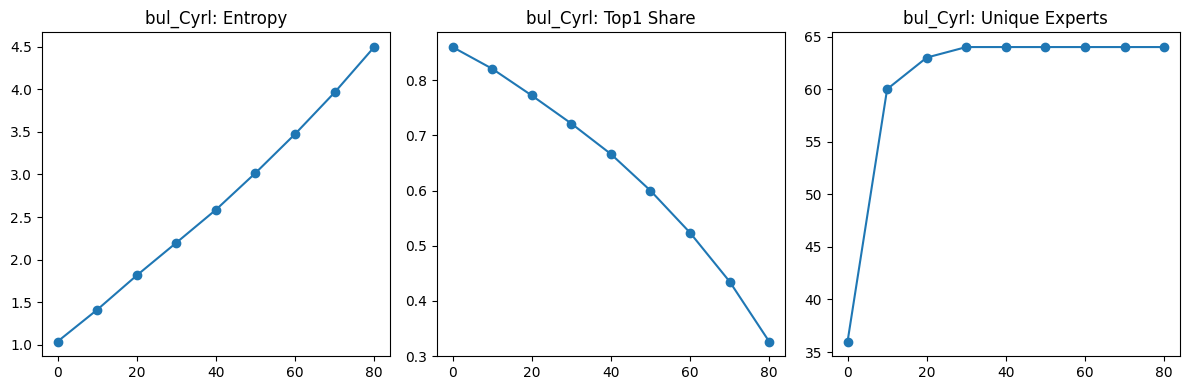

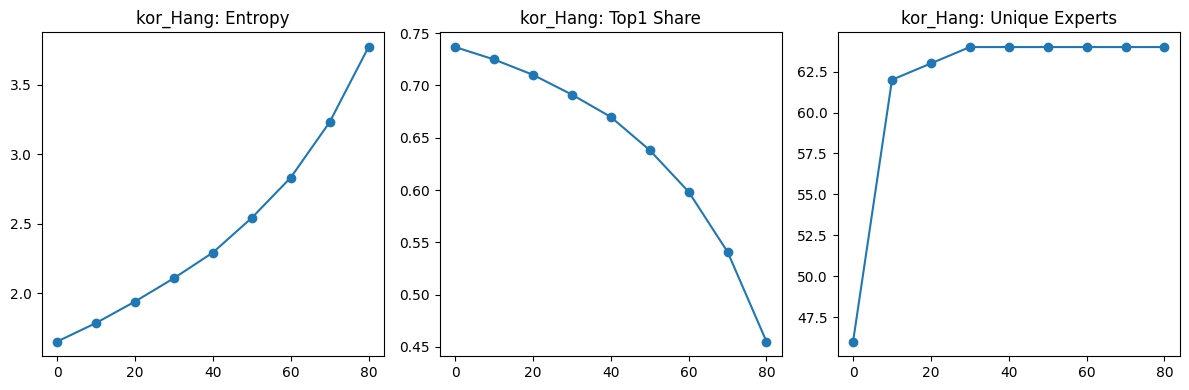

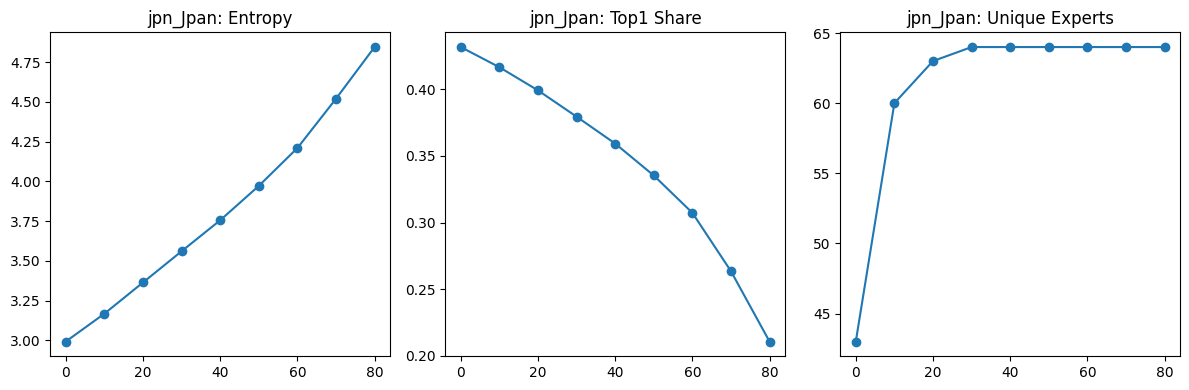

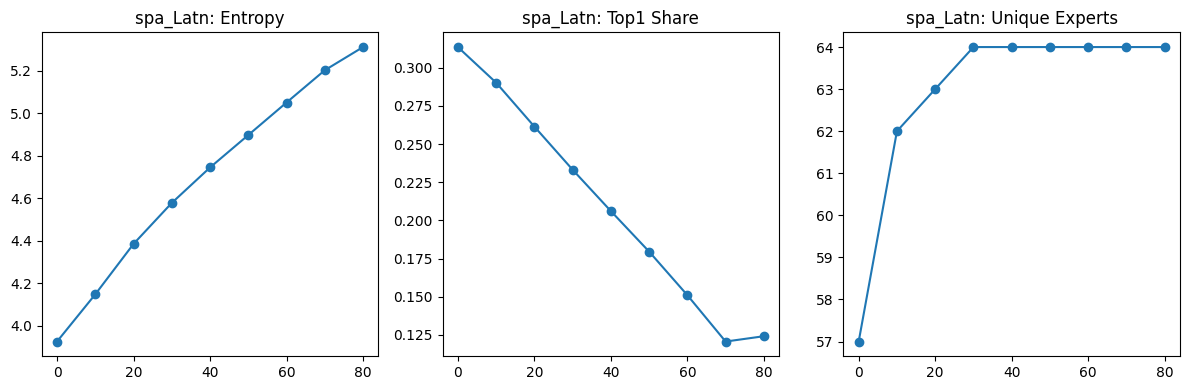

In [4]:
for tgt in target_langs:

    entropies=[]
    top1=[]
    unique=[]

    for r in ratios:
        df=pd.read_csv(f"router_logs_eng_{tgt}_{r}.csv")

        counts=df["expert_id"].value_counts()

        entropies.append(compute_entropy(counts.values))
        top1.append(counts.iloc[0]/counts.sum())
        unique.append(len(counts))

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.plot(ratios,entropies,marker='o')
    plt.title(f"{tgt}: Entropy")

    plt.subplot(1,3,2)
    plt.plot(ratios,top1,marker='o')
    plt.title(f"{tgt}: Top1 Share")

    plt.subplot(1,3,3)
    plt.plot(ratios,unique,marker='o')
    plt.title(f"{tgt}: Unique Experts")

    plt.tight_layout()
    plt.show()

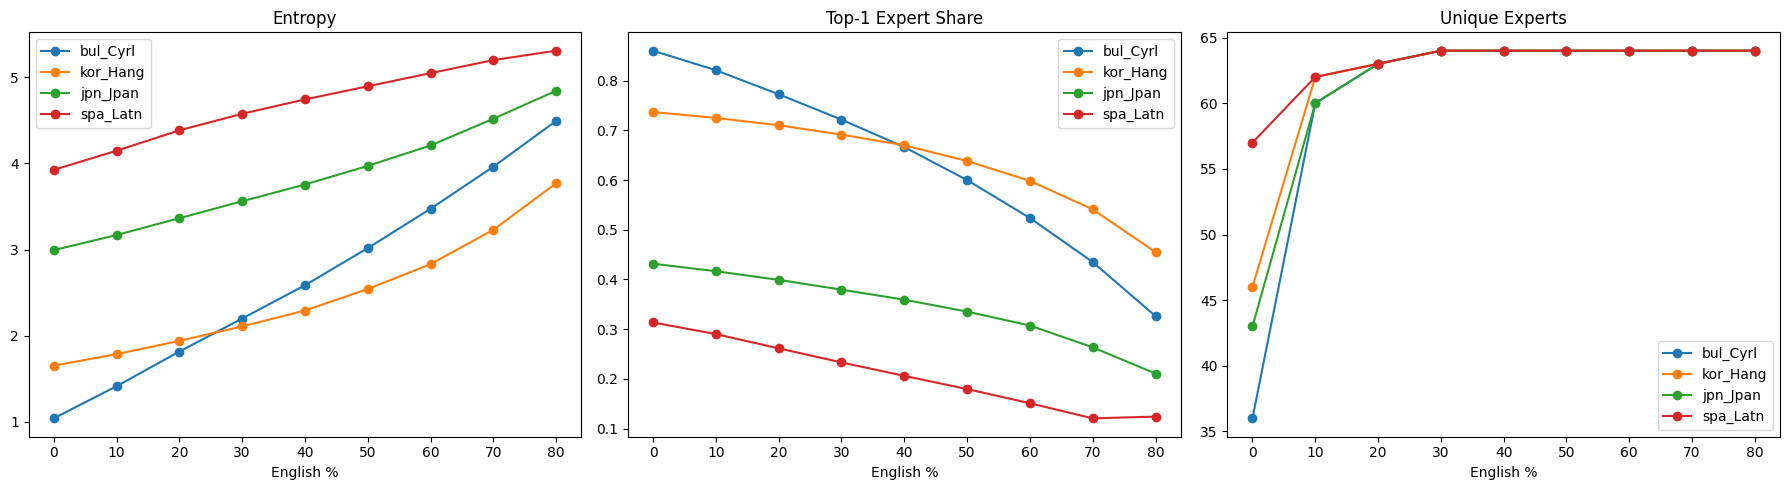

In [5]:
fig, axs = plt.subplots(1,3,figsize=(18,5))

for tgt in target_langs:

    entropies=[]
    top1=[]
    unique=[]

    for r in ratios:
        df = pd.read_csv(f"router_logs_eng_{tgt}_{r}.csv")
        counts = df["expert_id"].value_counts()

        entropies.append(compute_entropy(counts.values))
        top1.append(counts.iloc[0]/counts.sum())
        unique.append(len(counts))

    axs[0].plot(ratios, entropies, marker='o', label=tgt)
    axs[1].plot(ratios, top1, marker='o', label=tgt)
    axs[2].plot(ratios, unique, marker='o', label=tgt)

axs[0].set_title("Entropy")
axs[1].set_title("Top-1 Expert Share")
axs[2].set_title("Unique Experts")

for ax in axs:
    ax.set_xlabel("English %")
    ax.legend()

plt.tight_layout()
plt.show()